In [7]:
import torch
import datasets
import matplotlib.pyplot as plt

from model_loader import make_model, DEVICE

model = make_model(
    model_type="splitnet",
    channels="KP"
)
model.load_state_dict(torch.load(
    # "official_darcy/final/border_physics_limited_splitnet_attn_darcy_1p0_best_state.pt",
    # "baseline_full/final/border_splitnet_attn_baseline_full_nodarcy_best_state.pt",
    # "recent_analysis_unet/physics_tests/fixed/fixed_physics_limited_attn_unet_darcy_0p0_best_state.pt",
    # "official_darcy/final/border_physics_limited_splitnet_attn_darcy_5p0_best_state.pt",
    # "baseline_full/final/border_prof_unet_baseline_full_nodarcy_best_state.pt",
    # "baseline_full/final/border_unetfixed_baseline_full_nodarcy_best_state.pt",
    "limited_prior_tests2/border_splitnet_physics_limited_mask_mse_darcy_tvP_stats_best_state.pt",
    # "limited_prior_tests/border_splitnet_physics_limited_mask_mse_darcy_tvP_stats_best_state.pt",

    map_location=DEVICE
))

model.eval()

C:\Users\jaden\AppData\Local\Temp\ipykernel_14304\3361694476.py:11: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model.load_state_dict(torch.load(


SplitNet(
  (K_encode): Encode(
    (c1): TwoConv(
      (seq): Sequential(
        (0): Conv2d(1, 4, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
        (1): BatchNorm2d(4, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (2): ReLU()
        (3): Conv2d(4, 4, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
        (4): BatchNorm2d(4, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (5): ReLU()
      )
    )
    (d1): Downsample(
      (conv): TwoConv(
        (seq): Sequential(
          (0): Conv2d(4, 8, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
          (1): BatchNorm2d(8, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
          (2): ReLU()
          (3): Conv2d(8, 8, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
          (4): BatchNorm2d(8, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
          (5): ReLU()
        )
      )
      (pool): MaxPool2d(kernel_size=2, stride=2, pad

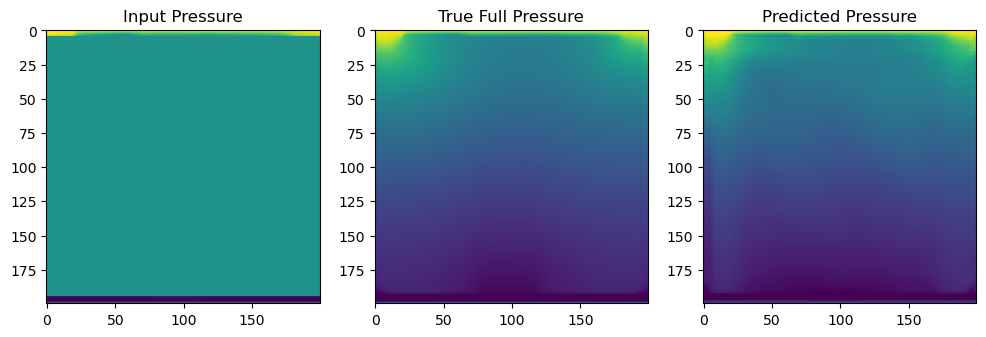

In [8]:
import numpy as np
import torch
import matplotlib.pyplot as plt
import datasets
from model_loader import make_model, DEVICE, ChannelSelectDataset

val_sims = np.array([123])

base_dataset = datasets.BorderDenseDatasetFull(
    sims=val_sims,
    channels="KP"
)

dataset = ChannelSelectDataset(base_dataset, channels="KP")
num = 155
feat, label = dataset[num]
# feat, label, msk = dataset[num]

with torch.no_grad():
    pred = model(feat.unsqueeze(0).to(DEVICE)).squeeze(0).cpu()

plt.figure(figsize=(12,4))

plt.subplot(1,3,1)
plt.imshow(feat[1].cpu())
plt.title("Input Pressure")

plt.subplot(1,3,2)
plt.imshow(label[1].cpu())
plt.title("True Full Pressure")

plt.subplot(1,3,3)
plt.imshow(pred[1])
plt.title("Predicted Pressure")

plt.show()

In [9]:
for name, x in [
    ("feat K", feat[0]),
    ("feat P", feat[1]),
    ("label K", label[0]),
    ("label P", label[1]),
    ("pred K", pred[0]),
    ("pred P", pred[1]),
]:
    print(name, x.min().item(), x.max().item(), x.mean().item())

feat K -1.0 0.0 -0.011175976134836674
feat P -1.0 0.96875 -0.009207617491483688
label K -1.0 -0.0625 -0.24082323908805847
label P -1.0 0.96875 -0.4355863332748413
pred K -0.9999998807907104 0.030361218377947807 -0.21232353150844574
pred P -1.0 0.8974727392196655 -0.4624953269958496


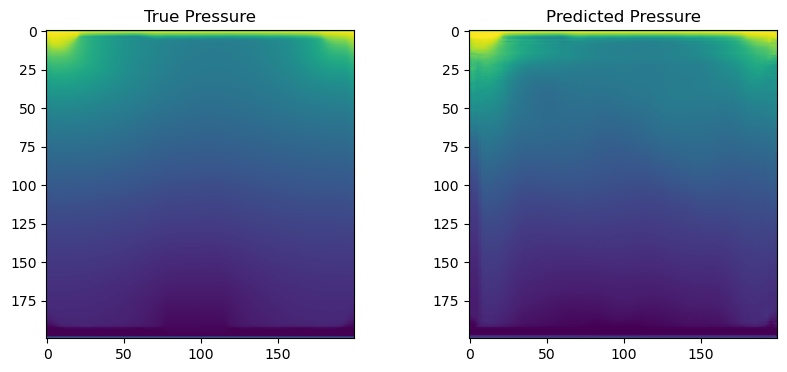

In [10]:
plt.figure(figsize=(10, 4))

plt.subplot(1, 2, 1)
plt.imshow(label[1].cpu())
plt.title("True Pressure")

plt.subplot(1, 2, 2)
plt.imshow(pred[1])
plt.title("Predicted Pressure")

plt.show()

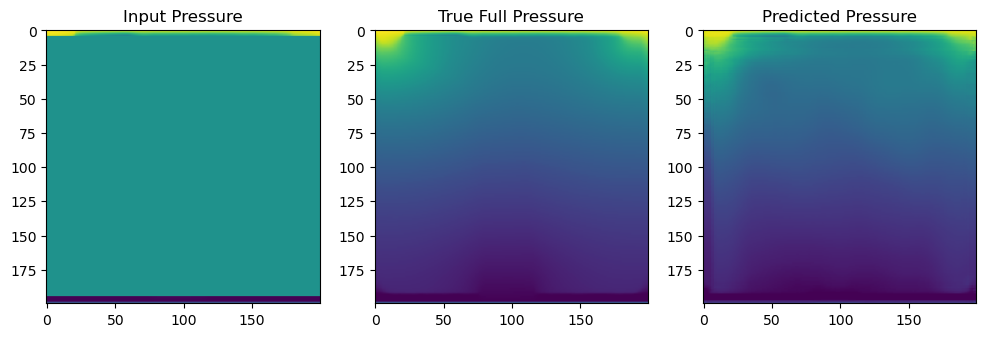

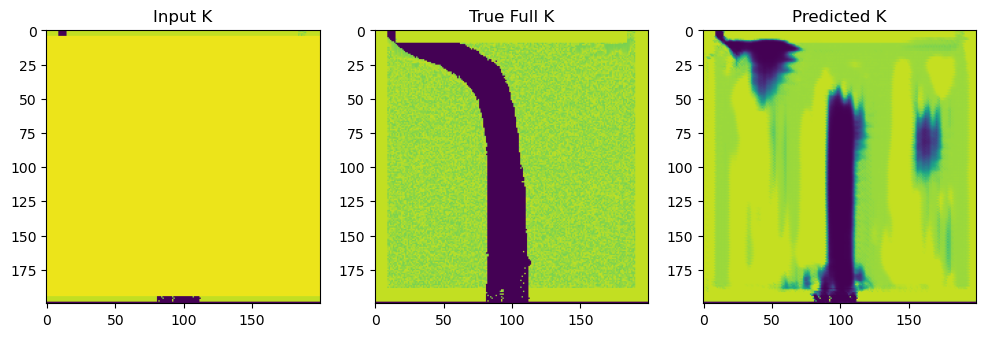

In [11]:
true_p = label[1].cpu()
pred_p = pred[1].cpu()

vmin = min(true_p.min().item(), pred_p.min().item())
vmax = max(true_p.max().item(), pred_p.max().item())

plt.figure(figsize=(12,4))

plt.subplot(1,3,1)
plt.imshow(feat[1].cpu(), vmin=vmin, vmax=vmax)
plt.title("Input Pressure")

plt.subplot(1,3,2)
plt.imshow(true_p, vmin=vmin, vmax=vmax)
plt.title("True Full Pressure")

plt.subplot(1,3,3)
plt.imshow(pred_p, vmin=vmin, vmax=vmax)
plt.title("Predicted Pressure")

plt.show()


true_k = label[0].cpu()
pred_k = pred[0].cpu()

vmin = min(true_k.min().item(), pred_k.min().item())
vmax = max(true_k.max().item(), pred_k.max().item())

plt.figure(figsize=(12,4))

plt.subplot(1,3,1)
plt.imshow(feat[0].cpu(), vmin=vmin, vmax=vmax)
plt.title("Input K")

plt.subplot(1,3,2)
plt.imshow(true_k, vmin=vmin, vmax=vmax)
plt.title("True Full K")

plt.subplot(1,3,3)
plt.imshow(pred_k, vmin=vmin, vmax=vmax)
plt.title("Predicted K")

plt.show()